In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [11]:
df = pd.read_csv("data/creditcard.csv")

In [3]:
import os

print(os.getcwd())

/Users/kenyaharvey/Desktop/fraud-detection-project


In [4]:
os.listdir()

['fraud_detection.ipynb',
 '.DS_Store',
 'images',
 'README.md',
 'data',
 'notebooks']

In [5]:
import os

os.listdir("data")

['creditcard.csv']

In [6]:
df = pd.read_csv("data/creditcard.csv")

In [7]:
import pandas as pd

df = pd.read_csv("data/creditcard.csv")

In [9]:
df = pd.read_csv("data/creditcard.csv")

In [9]:
os.listdir("data")

['creditcard.csv']

In [10]:
df = pd.read_csv("data/creditcard.csv")

In [11]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

## Class Imbalance Analysis

The dataset is highly imbalanced. The majority of transactions are legitimate, while fraudulent transactions represent only a very small percentage of the data.

Fraud detection is challenging because a model could predict every transaction as legitimate and still achieve very high accuracy. Therefore, evaluation metrics such as precision, recall, F1-score, and AUC-ROC are more useful than accuracy alone.

In [14]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

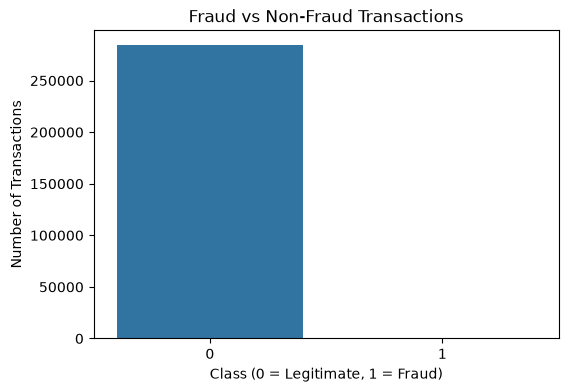

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

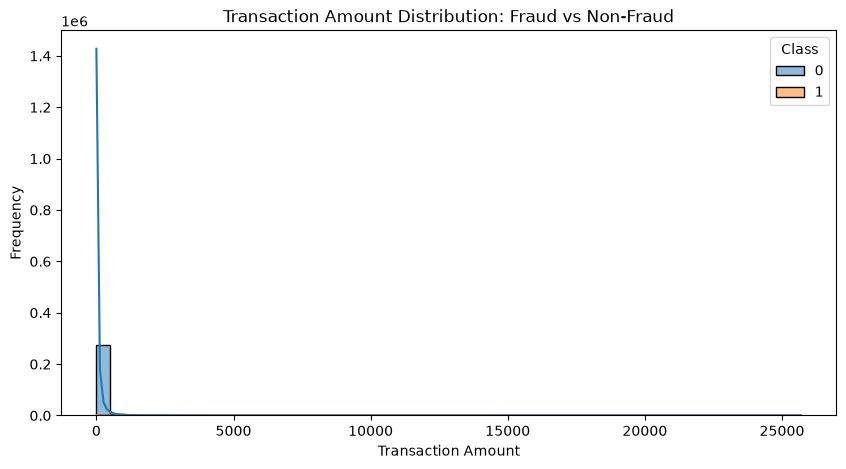

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [17]:
df["Hour"] = (df["Time"] / 3600) % 24

In [18]:
df[["Time", "Hour"]].head()

,Time,Hour
0,0.0,0.000000
1,0.0,0.000000
2,1.0,0.000278
3,1.0,0.000278
4,2.0,0.000556


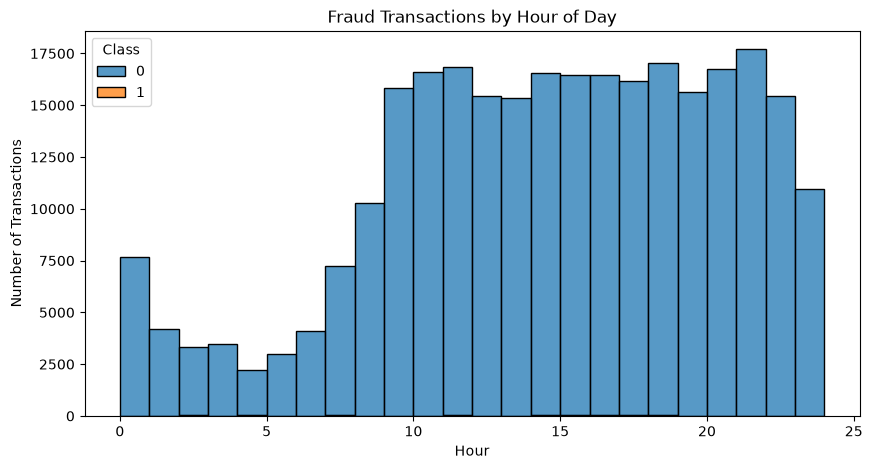

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Hour",
    hue="Class",
    bins=24,
    multiple="stack"
)

plt.title("Fraud Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")

plt.show()

## Exploratory Data Analysis (EDA)

### Fraud vs. Non-Fraud Distribution

The dataset contains a highly imbalanced target variable. Legitimate transactions represent the majority of records, while fraudulent transactions make up a very small percentage of the dataset. This imbalance is expected in real-world fraud detection problems and requires careful evaluation using metrics beyond accuracy.

### Transaction Amount Analysis

The transaction amount distribution was analyzed to compare fraudulent and legitimate transactions. Understanding transaction amounts helps identify whether fraudulent activity shows different spending patterns compared to normal transactions.

### Time-of-Day Analysis

The transaction time was converted into an hour-of-day feature to explore whether fraudulent transactions occur more frequently during specific times. Time-based patterns can provide useful signals for identifying suspicious transaction behavior.

### EDA Findings

- Fraudulent transactions are significantly fewer than legitimate transactions.
- Transaction amounts were compared between fraud and non-fraud cases.
- Transaction timing patterns were explored to identify possible periods of increased fraud activity.

These observations will help guide feature analysis and model development.

In [20]:
df["Hour"] = (df["Time"] / 3600) % 24

In [21]:
df[["Time", "Hour"]].head()

,Time,Hour
0,0.0,0.000000
1,0.0,0.000000
2,1.0,0.000278
3,1.0,0.000278
4,2.0,0.000556


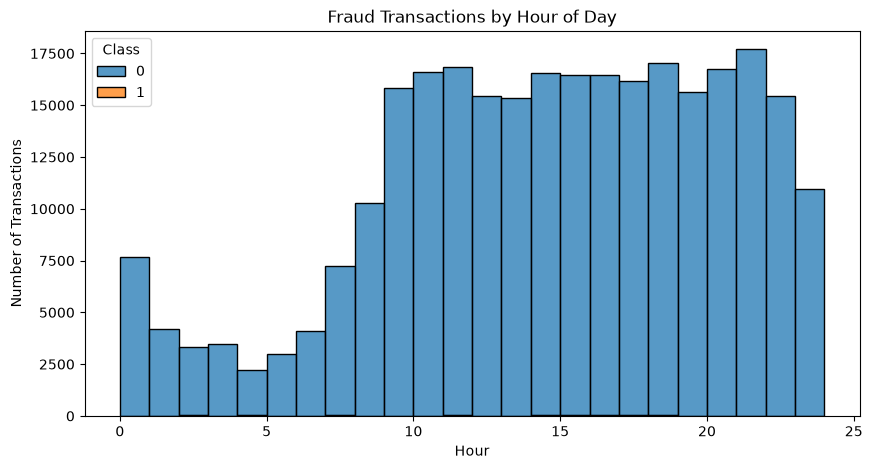

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Hour",
    hue="Class",
    bins=24,
    multiple="stack"
)

plt.title("Fraud Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")

plt.show()

## Why Accuracy Is Misleading for Fraud Detection

Accuracy is not a reliable evaluation metric for fraud detection because the dataset is highly imbalanced. The number of legitimate transactions is much larger than the number of fraudulent transactions.

A model could predict every transaction as legitimate and still achieve very high accuracy while failing to detect actual fraud cases.

For example, if fraud represents only a small percentage of transactions, a model that ignores all fraud cases could appear successful based on accuracy alone. Metrics such as precision, recall, F1-score, and AUC-ROC provide a better understanding of how well the model identifies fraudulent transactions.

Recall is especially important because it measures the percentage of actual fraud cases that the model successfully detects.

In [23]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [24]:
print(X.shape)
print(y.shape)

(284807, 31)
(284807,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [1]:
from imblearn.over_sampling import SMOTE

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv("data/creditcard.csv")

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df["Hour"] = (df["Time"] / 3600) % 24

In [8]:
from imblearn.over_sampling import SMOTE

In [3]:
# This cell should be deleted or left empty.
# The SMOTE resampling code is already in CELL INDEX 41 after train_test_split is executed.

In [10]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(227845, 31)
(56962, 31)
(227845,)
(56962,)


In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [14]:
print(y_train_resampled.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [17]:
logistic_model.fit(
    X_train_resampled,
    y_train_resampled
)

/opt/anaconda3/envs/northstar/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [18]:
y_pred_logistic = logistic_model.predict(X_test)

y_prob_logistic = logistic_model.predict_proba(X_test)[:,1]

In [19]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [20]:
precision = precision_score(y_test, y_pred_logistic)

recall = recall_score(y_test, y_pred_logistic)

f1 = f1_score(y_test, y_pred_logistic)

auc = roc_auc_score(y_test, y_prob_logistic)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC-ROC:", auc)
print("Classification Report:")

Precision: 0.11748998664886515
Recall: 0.8979591836734694
F1 Score: 0.2077922077922078
AUC-ROC: 0.9759349733844016
Classification Report:


In [21]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [23]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [24]:
rf_model.fit(
    X_train_resampled,
    y_train_resampled
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [25]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [26]:
precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)
print("AUC-ROC:", auc_rf)

Precision: 0.8383838383838383
Recall: 0.8469387755102041
F1 Score: 0.8426395939086294
AUC-ROC: 0.9693196549159899


In [27]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.85      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [28]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_rf
    ],
    "F1 Score": [
        f1,
        f1_rf
    ],
    "AUC-ROC": [
        auc,
        auc_rf
    ]
})

results

,Model,Precision,Recall,F1 Score,AUC-ROC
0,Logistic Regression,0.117490,0.897959,0.207792,0.975935
1,Random Forest,0.838384,0.846939,0.842640,0.969320


## Model Comparison and Metric Importance

Both Logistic Regression and Random Forest were evaluated using precision, recall, F1-score, and AUC-ROC instead of accuracy because fraud detection datasets are highly imbalanced.

Recall is especially important in fraud detection because missing a fraudulent transaction can result in financial losses. A model with high recall identifies more actual fraud cases.

However, increasing recall may also increase false positives, where legitimate transactions are incorrectly flagged as fraud. Precision helps measure how often fraud predictions are actually correct.

The best model should balance recall and precision while maintaining strong overall performance based on the business goals of the fraud detection system.

In [29]:
from sklearn.metrics import roc_curve, auc

# Logistic Regression ROC
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

auc_logistic = auc(fpr_logistic, tpr_logistic)
auc_random_forest = auc(fpr_rf, tpr_rf)

In [33]:
plt.show()

In [34]:
plt.savefig("images/roc_curve.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

/var/folders/ql/lmx1cprj1l1cjx478ft3c9840000gn/T/ipykernel_9434/1143181133.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


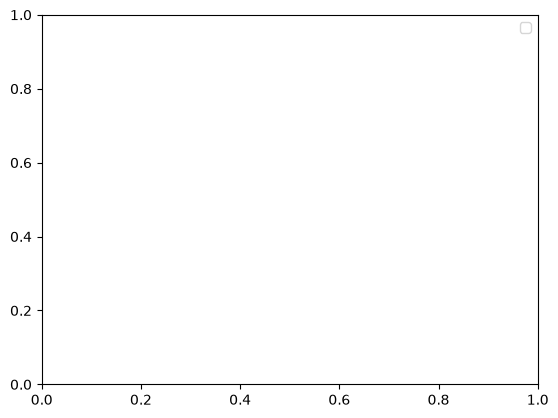

In [35]:
plt.legend()

plt.savefig("images/roc_curve.png", bbox_inches="tight")

plt.show()

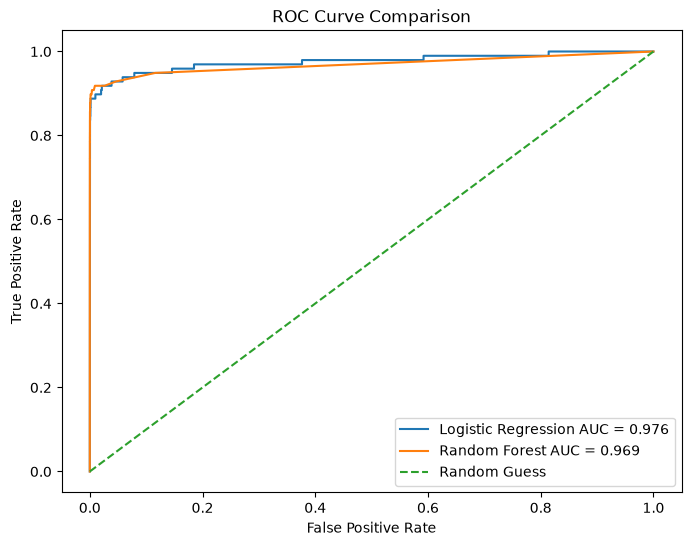

In [30]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression AUC = {auc_logistic:.3f}"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC = {auc_random_forest:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [31]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,V14,0.226625
10,V10,0.158837
4,V4,0.111695
12,V12,0.090744
11,V11,0.070616
17,V17,0.067564
3,V3,0.053759
16,V16,0.029811
7,V7,0.027813
2,V2,0.023758


In [36]:
plt.savefig("images/feature_importance.png", bbox_inches="tight")

plt.show()

<Figure size 640x480 with 0 Axes>

In [37]:
plt.show()

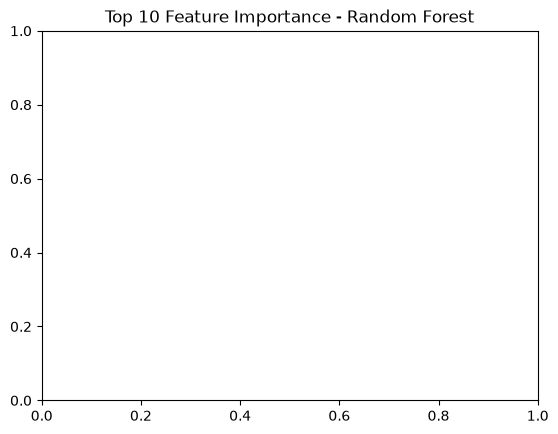

In [38]:
plt.title("Top 10 Feature Importance - Random Forest")

plt.savefig("images/feature_importance.png", bbox_inches="tight")

plt.show()

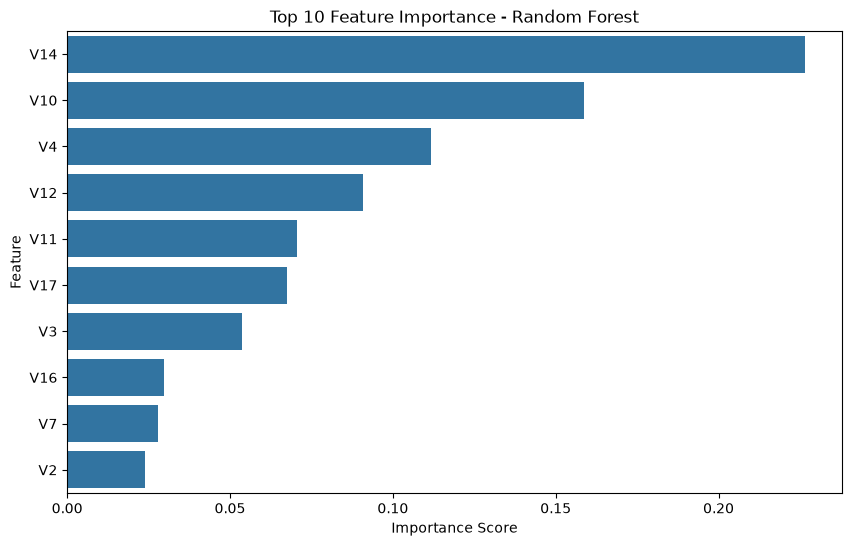

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## Feature Importance Analysis

Feature importance analysis shows which variables contributed most to the Random Forest model's fraud predictions.

The model uses these features to identify patterns that separate fraudulent transactions from legitimate transactions. Higher importance scores indicate that the feature had more influence on the model's decision-making process.

Understanding feature importance improves model interpretability and helps identify patterns that may be useful for future fraud detection systems.

## Scalability Considerations

A fraud detection system processing 1 million transactions per hour would require a scalable machine learning pipeline designed for high-volume, real-time data.

The model could be deployed as a real-time prediction service where incoming transactions are processed through the same feature engineering steps used during training. Technologies such as cloud computing, distributed data processing, and streaming platforms could help handle large transaction volumes.

To improve performance at scale:
- Use optimized data pipelines for faster feature processing
- Deploy the model as an API service for real-time predictions
- Use distributed computing tools such as Spark for large datasets
- Monitor model performance and retrain regularly as fraud patterns change
- Store predictions and transaction outcomes for future model improvements

For extremely high transaction volumes, the system should prioritize low latency while maintaining strong recall to reduce missed fraudulent transactions.